In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

In [50]:
df = pd.read_csv('../data/processed_data.csv')
df.head()

,price,freight_value,payment_value,payment_installments,product_weight_g,customer_state,seller_state,customer_lat,customer_lng,seller_lat,seller_lng,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_estimated_delivery_date,delayed,carrier_missing,purchase_hour,purchase_day,purchase_month,purchase_weekday,processing_time,estimated_delivery_time,same_state,lat_diff,lng_diff,total_cost,weight_category
0,58.90,13.29,72.19,2.0,650.0,RJ,SP,-21.762775,-41.309633,-22.496953,-44.127492,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-29,0,0,8,13,9,2,6,15,0,0.734177,2.817859,72.19,medium
1,239.90,19.93,259.83,3.0,4050.0,SP,SP,-20.220527,-50.903424,-23.565096,-46.518565,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-15,0,0,10,26,4,2,8,18,1,3.344569,4.384859,259.83,heavy
2,199.00,17.87,216.87,5.0,3050.0,MG,MG,-19.870305,-44.593326,-22.262584,-46.171124,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-02-05,0,0,14,14,1,6,1,21,1,2.392279,1.577798,216.87,heavy
3,12.99,12.79,25.78,2.0,200.0,SP,SP,-23.089925,-46.611654,-20.553624,-47.387359,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-20,0,0,10,8,8,2,2,11,1,2.536302,0.775705,25.78,light
4,199.90,18.14,218.04,3.0,3750.0,SP,PR,-23.243402,-46.827614,-22.929384,-53.135873,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-17,0,0,13,4,2,5,11,40,0,0.314018,6.308258,218.04,heavy


In [51]:
df.shape

(99441, 28)

In [52]:
df.isnull().sum()

price                            0
freight_value                    0
payment_value                    0
payment_installments             0
product_weight_g                 0
customer_state                   0
seller_state                     0
customer_lat                     0
customer_lng                     0
seller_lat                       0
seller_lng                       0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_estimated_delivery_date    0
delayed                          0
carrier_missing                  0
purchase_hour                    0
purchase_day                     0
purchase_month                   0
purchase_weekday                 0
processing_time                  0
estimated_delivery_time          0
same_state                       0
lat_diff                         0
lng_diff                         0
total_cost                       0
weight_category                  0
dtype: int64

In [53]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   price                          99441 non-null  float64
 1   freight_value                  99441 non-null  float64
 2   payment_value                  99441 non-null  float64
 3   payment_installments           99441 non-null  float64
 4   product_weight_g               99441 non-null  float64
 5   customer_state                 99441 non-null  str    
 6   seller_state                   99441 non-null  str    
 7   customer_lat                   99441 non-null  float64
 8   customer_lng                   99441 non-null  float64
 9   seller_lat                     99441 non-null  float64
 10  seller_lng                     99441 non-null  float64
 11  order_purchase_timestamp       99441 non-null  str    
 12  order_approved_at              99441 non-null  str    
 1

In [54]:
# Dropping unnecessary columns because relevant features have been extracted.
df.drop(columns=['customer_lat', 'customer_lng', 'seller_lat', 'seller_lng', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_estimated_delivery_date'], inplace=True)

In [55]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   price                    99441 non-null  float64
 1   freight_value            99441 non-null  float64
 2   payment_value            99441 non-null  float64
 3   payment_installments     99441 non-null  float64
 4   product_weight_g         99441 non-null  float64
 5   customer_state           99441 non-null  str    
 6   seller_state             99441 non-null  str    
 7   delayed                  99441 non-null  int64  
 8   carrier_missing          99441 non-null  int64  
 9   purchase_hour            99441 non-null  int64  
 10  purchase_day             99441 non-null  int64  
 11  purchase_month           99441 non-null  int64  
 12  purchase_weekday         99441 non-null  int64  
 13  processing_time          99441 non-null  int64  
 14  estimated_delivery_time  99441 no

In [56]:
# Ordinal Encoding
weight_map = {
    'light': 0,
    'medium': 1,
    'heavy': 2,
    'very_heavy': 3
}

df['weight_category'] = df['weight_category'].map(weight_map)

In [57]:
# One-hot encoding for categorical variables
df = pd.get_dummies(df, columns=['customer_state', 'seller_state'], dtype=int , drop_first=True)

In [58]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 66 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   price                    99441 non-null  float64
 1   freight_value            99441 non-null  float64
 2   payment_value            99441 non-null  float64
 3   payment_installments     99441 non-null  float64
 4   product_weight_g         99441 non-null  float64
 5   delayed                  99441 non-null  int64  
 6   carrier_missing          99441 non-null  int64  
 7   purchase_hour            99441 non-null  int64  
 8   purchase_day             99441 non-null  int64  
 9   purchase_month           99441 non-null  int64  
 10  purchase_weekday         99441 non-null  int64  
 11  processing_time          99441 non-null  int64  
 12  estimated_delivery_time  99441 non-null  int64  
 13  same_state               99441 non-null  int64  
 14  lat_diff                 99441 no

In [59]:
# Split the data into X and y variable
from sklearn.model_selection import train_test_split
X = df.drop('delayed', axis=1)
y = df['delayed']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [60]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression Model
* It predicts the probability that an input belongs to a specific class.

In [61]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

lr_model = LogisticRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr) * 100, "%")
print("Classification Report:\n", classification_report(y_test, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))

Logistic Regression Accuracy: 92.55870078938106 %
Classification Report:
               precision    recall  f1-score   support

           0       0.93      1.00      0.96     18324
           1       0.69      0.10      0.17      1565

    accuracy                           0.93     19889
   macro avg       0.81      0.55      0.57     19889
weighted avg       0.91      0.93      0.90     19889

Confusion Matrix:
 [[18254    70]
 [ 1410   155]]


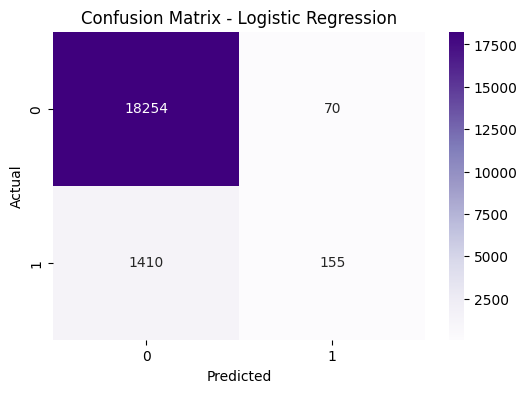

In [62]:
plt.figure(figsize=(6, 4))
cm_svm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Purples')
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Support Vector Machine Model
* It tries to find the best boundary known as hyperplane that separates different classes in the data. 

In [ ]:
from sklearn.svm import SVC
svm_model = SVC(random_state=42)
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm) * 100, "%")
print("Classification Report:\n", classification_report(y_test, y_pred_svm))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))

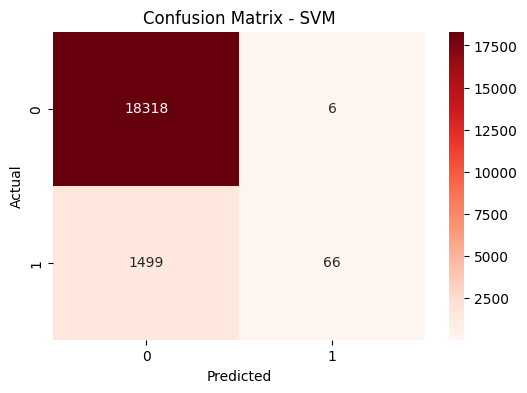

In [ ]:
plt.figure(figsize=(6, 4))
cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Reds')
plt.title('Confusion Matrix - SVM')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# K-Nearest Neighbors Model
* It works by identifying the K closest data points to a given input and making predictions based on the majority class or average value of those neighbors.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn) * 100, "%")
print("Classification Report:\n", classification_report(y_test, y_pred_knn))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))

KNN Accuracy: 92.07099401679321 %
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.99      0.96     18324
           1       0.48      0.09      0.16      1565

    accuracy                           0.92     19889
   macro avg       0.70      0.54      0.56     19889
weighted avg       0.89      0.92      0.90     19889

Confusion Matrix:
 [[18167   157]
 [ 1420   145]]


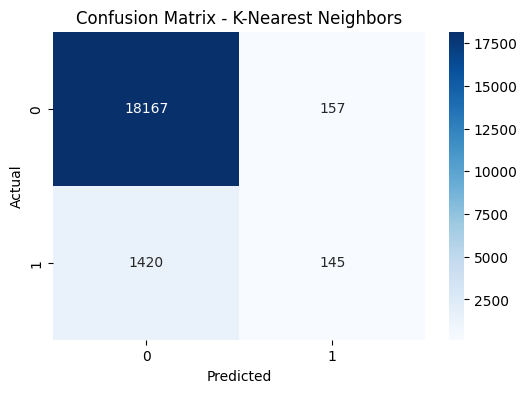

In [ ]:
plt.figure(figsize=(6, 4))
cm_knn = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - K-Nearest Neighbors')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Naive Bayes
* It assumes that all features are independent of each other.

In [ ]:
from sklearn.naive_bayes import GaussianNB
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)
y_pred_nb = nb_model.predict(X_test_scaled)
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb) * 100, "%")
print("Classification Report:\n", classification_report(y_test, y_pred_nb)) 
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))

Naive Bayes Accuracy: 11.166976720800442 %
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.04      0.07     18324
           1       0.08      0.99      0.15      1565

    accuracy                           0.11     19889
   macro avg       0.53      0.51      0.11     19889
weighted avg       0.91      0.11      0.08     19889

Confusion Matrix:
 [[  671 17653]
 [   15  1550]]


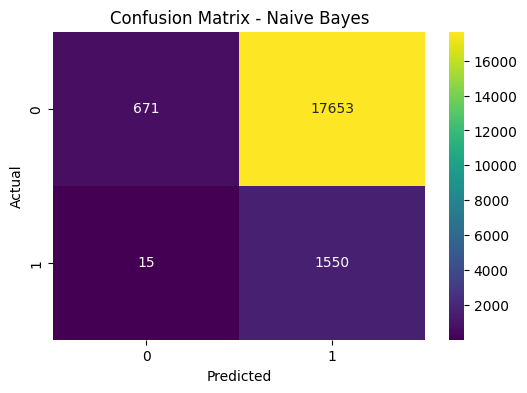

In [ ]:
plt.figure(figsize=(6, 4))
cm_nb = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='viridis')
plt.title('Confusion Matrix - Naive Bayes')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Decision Tree Model
* A Decision Tree helps us to make decisions by mapping out different choices and their possible outcomes.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)
y_pred_dt = dt_model.predict(X_test_scaled)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt) * 100, "%")
print("Classification Report:\n", classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 87.98833526069687 %
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.93      0.93     18324
           1       0.27      0.30      0.28      1565

    accuracy                           0.88     19889
   macro avg       0.60      0.61      0.61     19889
weighted avg       0.89      0.88      0.88     19889



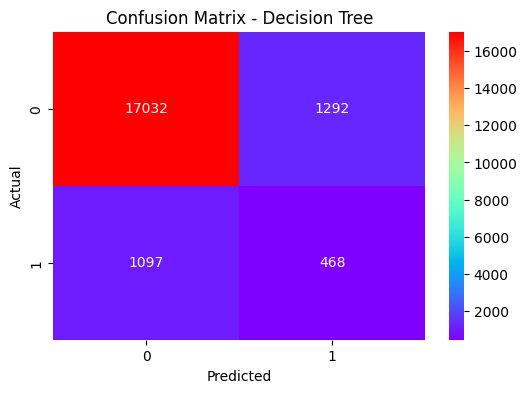

In [ ]:
plt.figure(figsize=(6, 4))
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='rainbow')
plt.title('Confusion Matrix - Decision Tree')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Random Forest Model
* Random Forest is an ensemble machine learning algorithm that builds multiple decision trees and combines their predictions to improve accuracy and reduce overfitting.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf) * 100, "%")
print("Classification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 92.5637286942531 %
Classification Report:
               precision    recall  f1-score   support

           0       0.93      1.00      0.96     18324
           1       0.78      0.08      0.14      1565

    accuracy                           0.93     19889
   macro avg       0.85      0.54      0.55     19889
weighted avg       0.91      0.93      0.90     19889



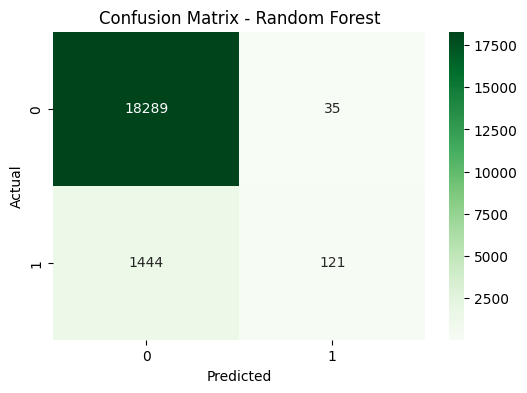

In [ ]:
plt.figure(figsize=(6, 4))
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Adaboost Model
* AdaBoost means Adaptive Boosting which is a ensemble learning technique that combines multiple weak classifiers to create a strong classifier.

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
adaboost_model = AdaBoostClassifier(random_state=42)
adaboost_model.fit(X_train_scaled, y_train)
y_pred_adaboost = adaboost_model.predict(X_test_scaled)
print("AdaBoost Accuracy:", accuracy_score(y_test, y_pred_adaboost) * 100, "%")
print("Classification Report:\n", classification_report(y_test, y_pred_adaboost))

AdaBoost Accuracy: 92.21177535321031 %
Classification Report:
               precision    recall  f1-score   support

           0       0.92      1.00      0.96     18324
           1       0.90      0.01      0.02      1565

    accuracy                           0.92     19889
   macro avg       0.91      0.51      0.49     19889
weighted avg       0.92      0.92      0.89     19889



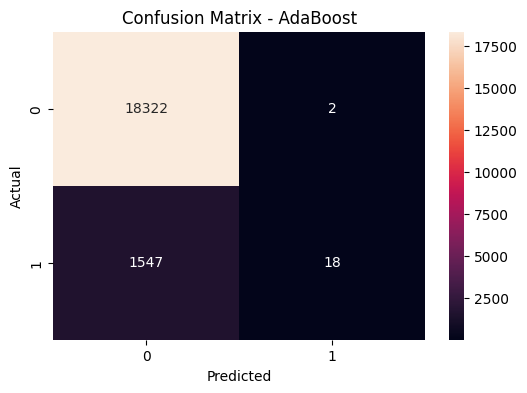

In [ ]:
plt.figure(figsize=(6, 4))
cm_ab = confusion_matrix(y_test, y_pred_adaboost)
sns.heatmap(cm_ab, annot=True, fmt='d', cmap='rocket')
plt.title('Confusion Matrix - AdaBoost')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Model Selection

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced', random_state=42),
    "Logistic Regression": LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    "Support Vector Classifier": SVC(class_weight='balanced', random_state=42),
    "K-Neighbors Classifier": KNeighborsClassifier(n_neighbors=5),
    "AdaBoost Classifier": AdaBoostClassifier(random_state=42),
    "Naive Bayes": GaussianNB()
}
results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred) * 100
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    # Append results to the list
    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })
performance_df = pd.DataFrame(results)
performance_df = performance_df.sort_values(by='Recall', ascending=False).reset_index(drop=True)
print(performance_df)


                       Model   Accuracy  Precision    Recall  F1-Score
0                Naive Bayes  11.166977   0.080717  0.990415  0.149268
1  Support Vector Classifier  75.137010   0.193174  0.679872  0.300862
2        Logistic Regression  71.275579   0.168902  0.676038  0.270277
3              Decision Tree  88.491126   0.280872  0.296486  0.288468
4              Random Forest  92.498366   0.558966  0.221086  0.316850
5     K-Neighbors Classifier  92.070994   0.480132  0.092652  0.155329
6        AdaBoost Classifier  92.211775   0.900000  0.011502  0.022713


In [ ]:
# Identified best Model
best_model_name = performance_df.loc[0, 'Model']
best_model_accuracy = performance_df.loc[0, 'Recall']
print(f"Best Model: {best_model_name} with Recall: {best_model_accuracy:.2f}%")

Best Model: Naive Bayes with Recall: 0.99%


# Model Summary
* Naive Bayes achieved the highest recall (99.04%), but at the cost of extremely low precision (8.07%) and low accuracy (11.17%), resulting in too many false alarms. Therefore, Support Vector Machine was selected as the final model because it provided a better balance between identifying delayed orders and minimizing unnecessary interventions, achieving a recall of 68% and the highest F1-score of 0.30.

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix

linear_svc = LinearSVC(
    class_weight='balanced',
    random_state=42,
    max_iter=5000
)

linear_svc.fit(X_train_scaled, y_train)

y_pred = linear_svc.predict(X_test_scaled)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.72      0.82     18324
           1       0.17      0.67      0.27      1565

    accuracy                           0.72     19889
   macro avg       0.57      0.70      0.55     19889
weighted avg       0.90      0.72      0.78     19889

[[13181  5143]
 [  515  1050]]


# Feature Selection

In [ ]:
feature_importance = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': linear_svc.coef_[0]})

feature_importance['Abs_Coefficient'] = (feature_importance['Coefficient'].abs())

feature_importance = feature_importance.sort_values(by='Abs_Coefficient', ascending=False)

print(feature_importance.head(20))

                    Feature  Coefficient  Abs_Coefficient
5           carrier_missing    -0.821159         0.821159
11  estimated_delivery_time    -0.480250         0.480250
10          processing_time     0.388638         0.388638
12               same_state    -0.171267         0.171267
34        customer_state_RJ     0.171025         0.171025
14                 lng_diff     0.096242         0.096242
13                 lat_diff     0.093393         0.093393
8            purchase_month    -0.091587         0.091587
20        customer_state_BA     0.081932         0.081932
29        customer_state_PA     0.066639         0.066639
39        customer_state_SC     0.064140         0.064140
2             payment_value    -0.062112         0.062112
38        customer_state_RS     0.058644         0.058644
64          seller_state_SP     0.055691         0.055691
61          seller_state_RS    -0.053799         0.053799
17        customer_state_AL     0.046770         0.046770
25        cust

# Hyperparameter Tuning to increase model performance

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC

# Define the parameter grid for LinearSVC
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'loss': ['hinge', 'squared_hinge']
}

In [ ]:
# Initialize GridSearchCV
grid_search = GridSearchCV(
    LinearSVC(class_weight='balanced', random_state=42, max_iter=5000),
    param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)


In [ ]:
# Fit GridSearchCV to the training data
grid_search.fit(X_train_scaled, y_train)

# Print the best parameters and best score
print("Best parameters found: ", grid_search.best_params_)
print("Best recall score found: ", grid_search.best_score_)

# Get the best estimator
best_linear_svc = grid_search.best_estimator_


Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters found:  {'C': 0.001, 'loss': 'squared_hinge', 'penalty': 'l1'}
Best recall score found:  0.7016903839730333


In [ ]:
y_pred_tuned = best_linear_svc.predict(X_test_scaled)

print("Tuned LinearSVC Classification Report:\n", classification_report(y_test, y_pred_tuned))
print("Tuned LinearSVC Confusion Matrix:\n", confusion_matrix(y_test, y_pred_tuned))

Tuned LinearSVC Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.71      0.82     18324
           1       0.17      0.68      0.27      1565

    accuracy                           0.71     19889
   macro avg       0.57      0.70      0.54     19889
weighted avg       0.90      0.71      0.78     19889

Tuned LinearSVC Confusion Matrix:
 [[13066  5258]
 [  500  1065]]


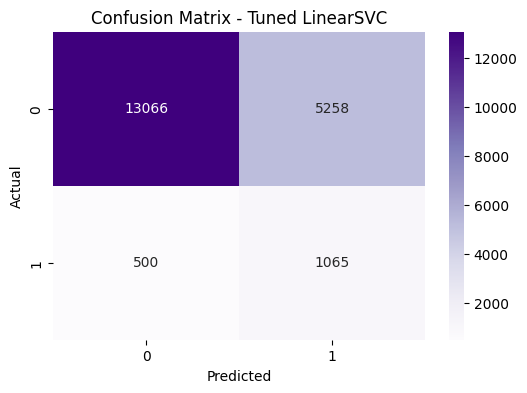

In [ ]:
plt.figure(figsize=(6, 4))
cm_tuned_svc = confusion_matrix(y_test, y_pred_tuned)
sns.heatmap(cm_tuned_svc, annot=True, fmt='d', cmap='Purples')
plt.title('Confusion Matrix - Tuned LinearSVC')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [ ]:
# Feature importance for the best LinearSVC model
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": np.abs(best_linear_svc.coef_[0])
})

importance = importance.sort_values(
    by="importance",
    ascending=False
)

print(importance.head(20))

ValueError: All arrays must be of the same length